In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy import stats

In [2]:
# Load scaler and PCA objects
scaler = joblib.load('scaler.pkl')
pca = joblib.load('pca_normal_baseline.pkl')

# PCA data for T2
fftr_pca   = np.load('fftr_pca.npy')  # Normal Training
fftest_pca = np.load('fft_pca.npy')   # Normal Testing 
ftest_pca  = np.load('ftr_pca.npy')    # Faulty training 

# Scaled Data for SPE 
fftr_scaled   = np.load('fftr_scaled.npy')   # Normal Training
fftest_scaled = np.load('fftest_scaled.npy') # Normal Testing
ftest_scaled  = np.load('ftr_scaled.npy')  # Faulty training


# Load faulty testing labels
ft_labels  = np.load('ftr_labels.npy')


# ── Verify All Shapes ──
print("PCA Transformed Data:")
print(f"Normal Training:  {fftr_pca.shape}")
print(f"Normal Testing:   {fftest_pca.shape}")
print(f"Faulty Training:   {ftest_pca.shape}")

print("\nScaled Data:")
print(f"Normal Training:  {fftr_scaled.shape}")
print(f"Normal Testing:   {fftest_scaled.shape}")
print(f"Faulty Training:   {ftest_scaled.shape}")

print("\nLabels:")
print(f"Faulty Training:   {ft_labels.shape}")

PCA Transformed Data:
Normal Training:  (250000, 36)
Normal Testing:   (480000, 36)
Faulty Training:   (4800000, 36)

Scaled Data:
Normal Training:  (250000, 52)
Normal Testing:   (480000, 52)
Faulty Training:   (4800000, 52)

Labels:
Faulty Training:   (4800000,)


In [3]:
# SECTION 3: COMPUTE T² AND SPE STATISTICS

def compute_t2_spe(data_pca, data_scaled, pca_model):
    """
    Compute T² and SPE statistics for each sample.
    
    Parameters:
    ───────────
    data_pca    : PCA transformed data  
                  shape: (n_samples, n_components)
    data_scaled : Original scaled data  
                  shape: (n_samples, n_features)
    pca_model   : Fitted PCA object (from normal data)
    
    Returns:
    ────────
    t2  : T² statistic per sample (n_samples,)
    spe : SPE statistic per sample (n_samples,)
    """
    
    # ── T² Statistic ──
    # Measures deviation WITHIN PCA model
    # How far is sample from center of
    # normal operation in PC space?
    
    eigenvalues = pca_model.explained_variance_
    t2 = np.sum(
        (data_pca ** 2) / eigenvalues,
        axis=1
    )
    
    # ── SPE Statistic ──
    # Measures deviation OUTSIDE PCA model
    # How well does normal PCA reconstruct
    # this sample back to original space?
    
    # Step 1: Reconstruct from PCA back to
    #         original scaled space
    data_reconstructed = pca_model.inverse_transform(
        data_pca
    )
    
    # Step 2: SPE = squared difference between
    #         original scaled and reconstructed
    residuals = data_scaled - data_reconstructed
    spe = np.sum(residuals ** 2, axis=1)
    
    return t2, spe

print("T² and SPE function defined!")

T² and SPE function defined!


In [4]:
# SECTION 4: COMPUTE THRESHOLD FROM 
#            NORMAL TRAINING DATA

print("Computing T² and SPE for Normal Training data...")
t2_normal, spe_normal = compute_t2_spe(
    data_pca    = fftr_pca,
    data_scaled = fftr_scaled,
    pca_model   = pca
)

print(f"T²  shape: {t2_normal.shape}")
print(f"SPE shape: {spe_normal.shape}")

print(f"\nT²  statistics on Normal Training:")
print(f"Mean:  {t2_normal.mean():.4f}")
print(f"Std:   {t2_normal.std():.4f}")
print(f"Max:   {t2_normal.max():.4f}")
print(f"99th percentile: {np.percentile(t2_normal, 99):.4f}")

print(f"\nSPE statistics on Normal Training:")
print(f"Mean:  {spe_normal.mean():.4f}")
print(f"Std:   {spe_normal.std():.4f}")
print(f"Max:   {spe_normal.max():.4f}")
print(f"99th percentile: {np.percentile(spe_normal, 99):.4f}")

Computing T² and SPE for Normal Training data...
T²  shape: (250000,)
SPE shape: (250000,)

T²  statistics on Normal Training:
Mean:  35.9999
Std:   8.6142
Max:   84.8114
99th percentile: 58.5242

SPE statistics on Normal Training:
Mean:  2.1736
Std:   1.2485
Max:   15.0800
99th percentile: 6.1692


In [5]:
# SET DETECTION THRESHOLDS

# Set thresholds at 99th percentile
# of Normal Training statistics

t2_threshold  = np.percentile(t2_normal, 99)
spe_threshold = np.percentile(spe_normal, 99)

print("Detection Thresholds (99th percentile):")
print(f"T²  threshold: {t2_threshold:.4f}")
print(f"SPE threshold: {spe_threshold:.4f}")

# Save thresholds for deployment
joblib.dump(
    {'t2': t2_threshold, 'spe': spe_threshold},
    'thresholds.pkl'
)
print("\nThresholds saved!")

Detection Thresholds (99th percentile):
T²  threshold: 58.5242
SPE threshold: 6.1692

Thresholds saved!


In [6]:
# Step 1: Compute T² and SPE for faulty test data
print("Computing statistics for Faulty Testing...")
t2_faulty, spe_faulty = compute_t2_spe(
    data_pca    = ftest_pca,
    data_scaled = ftest_scaled,
    pca_model   = pca
)
print("Done!")

Computing statistics for Faulty Testing...
Done!


In [7]:
print(f"T²  faulty shape:  {t2_faulty.shape}")
print(f"SPE faulty shape:  {spe_faulty.shape}")


print(f"\nT²  statistics on Faulty Testing:")
print(f"Mean:            {t2_faulty.mean():.4f}")
print(f"99th percentile: {np.percentile(t2_faulty, 99):.4f}")
print(f"Max:             {t2_faulty.max():.4f}")

print(f"\nSPE statistics on Faulty Testing:")
print(f"Mean:            {spe_faulty.mean():.4f}")
print(f"99th percentile: {np.percentile(spe_faulty, 99):.4f}")
print(f"Max:             {spe_faulty.max():.4f}")

T²  faulty shape:  (4800000,)
SPE faulty shape:  (4800000,)

T²  statistics on Faulty Testing:
Mean:            1079.6189
99th percentile: 16195.9319
Max:             22939.2613

SPE statistics on Faulty Testing:
Mean:            663.2426
99th percentile: 17336.2047
Max:             24402.8942


In [8]:
# DETECTION RATE PER FAULT TYPE

print("="*70)
print(f"{'Fault':<8} {'T2 Rate':>12} {'SPE Rate':>12} {'Combined_OR':>12} {'Combined_AND':>12} {'Diff':>8}")
print("="*70)

for fault in sorted(np.unique(ft_labels)):
    
    # Get rows belonging to this fault
    fault_mask = ft_labels == fault
    
    # T² detection rate
    t2_rate = (
        t2_faulty[fault_mask] > t2_threshold
    ).mean() * 100
    
    # SPE detection rate
    spe_rate = (
        spe_faulty[fault_mask] > spe_threshold
    ).mean() * 100

    combined_OR = (
        (t2_faulty[fault_mask] > t2_threshold) |
        (spe_faulty[fault_mask] > spe_threshold)
    ).mean() * 100


    combined_AND = (
        (t2_faulty[fault_mask] > t2_threshold) &
        (spe_faulty[fault_mask] > spe_threshold)
    ).mean() * 100

    
    print(
        f"Fault {fault:<4}"
        f"{t2_rate:>10.2f}%"
        f"{spe_rate:>10.2f}%"
        f"{combined_OR:>12.2f}%"
        f"{combined_AND:>12.2f}%"
        f"{(combined_OR - combined_AND):>12.2f}%"
    )

print("="*70)

Fault         T2 Rate     SPE Rate  Combined_OR Combined_AND     Diff
Fault 1        99.01%     98.47%       99.67%       97.80%        1.87%
Fault 2        97.78%     96.45%       97.88%       96.35%        1.54%
Fault 3         1.05%      1.17%        2.21%        0.01%        2.19%
Fault 4        34.87%     99.89%       99.99%       34.77%       65.22%
Fault 5        38.78%     28.30%       44.55%       22.53%       22.03%
Fault 6        98.56%    100.00%      100.00%       98.56%        1.44%
Fault 7       100.00%     84.13%      100.00%       84.13%       15.87%
Fault 8        95.14%     87.65%       96.09%       86.70%        9.40%
Fault 9         1.09%      1.20%        2.28%        0.01%        2.27%
Fault 10       17.89%     45.65%       53.93%        9.61%       44.32%
Fault 11       47.18%     67.06%       81.11%       33.13%       47.98%
Fault 12       97.01%     92.87%       97.90%       91.97%        5.93%
Fault 13       90.12%     90.86%       91.74%       89.23%        

### Observation:
- Fault no. - 1,2,6,7,8,12,13,14,17,18 are easily detectable as with the introduction of these faults t2 value (deviation from the center of PCA space) increases above threshold as well as PCA structure also breaks (SPE).
- Introduction of Fault no. - 3, 9, 15 breaks the multivariability structure of normal operation along with its huge deviation from the center of PCA space. but these faults are not easily detectable.
-  We can categorize the faults into 4 categories:
   - I) High T2 and High SPE rate = Fault 1, Fault 2, Fault 6, Fault 7, Fault 8, Fault 12, Fault 13, Fault 14, Fault 17 and Fault 18.
   - II) High T2 and low SPE rate = None
   - III) Low T2 and High SPE rate = Fault 4, Fault 10, Fault 11, Fault 16, Fault 20 
   - IV) Low T2 and Low SPE rate = Fault 3, Fault 5, Fault 9, Fault 15, Fault 19
- SPE is more powerful than T2:
  - Normal PCA (36 components): Built on normal correlation structure
  - Faulty data needs only 10 components. Has different strucure 26 NEW variance directions emerge!
  - T2 limitation: Only measures deviation along normal PC directions (36 components). Faults in NEW directions invisible to T2.
  - SPE Measures reconstruction error when fault variance is in NEW directions. normal PCA completely fails to reconstruct. Large SPE signal even for subtle faults.


In [9]:
# Check false positive rate
print("Computing statistics for Normal testing data...")
t2_nor_test, spe_nor_test = compute_t2_spe(fftest_pca, fftest_scaled, pca)

#T2 and SPE statistics
print(f"T2 fault_free_shape: {t2_nor_test.shape}")
print(f"spe fault_free_shape: {spe_nor_test.shape}")

print(f"\nT2 statistics on fault free data")
print(f"Mean:            {t2_nor_test.mean():.4f}")
print(f"99th percentile: {np.percentile(t2_nor_test,99):.4f}")
print(f"Max:             {t2_nor_test.max():.4f}")

print(f"\nSPE statistics on fault free data")
print(f"Mean:            {spe_nor_test.mean():.4f}")
print(f"99th percentile: {np.percentile(spe_nor_test,99):.4f}")
print(f"Max:             {spe_nor_test.max():.4f}")


print("="*60)


t2_rate = (
    t2_nor_test > t2_threshold
).mean()*100


spe_rate = (
    spe_nor_test > spe_threshold
).mean()*100


combined_OR = (
    (t2_nor_test > t2_threshold) |
    (spe_nor_test > spe_threshold)
).mean()*100

combined_AND = (
    (t2_nor_test > t2_threshold) &
    (spe_nor_test > spe_threshold)
).mean()*100

print(
    f"T2 false positive rate {t2_rate:>10.2f}%"
    f"\nSPE false positive rate {spe_rate:>10.2f}%"
    f"\nCombined (OR) false positive rate {combined_OR:>10.2f}%"
    f"\nCombined (AND) false positive rate {combined_AND:>10.2f}%"
)

Computing statistics for Normal testing data...
T2 fault_free_shape: (480000,)
spe fault_free_shape: (480000,)

T2 statistics on fault free data
Mean:            36.2601
99th percentile: 58.7969
Max:             90.5754

SPE statistics on fault free data
Mean:            2.1966
99th percentile: 6.2088
Max:             13.6602
T2 false positive rate       1.06%
SPE false positive rate       1.04%
Combined (OR) false positive rate       2.08%
Combined (AND) false positive rate       0.01%


### Observation:
- Normal data needs 36 PCs to reconstruct 52 features with only 16 combinations needed — small reconstruction gap. Faulty data has 26 NEW directions outside normal PCA — large reconstruction gap. This gap IS the SPE signal, and OR logic ensures we catch faults detected by either statistic independently.

In [10]:
from scipy import stats

n = fftr_pca.shape[0]
p = fftr_pca.shape[1]
alpha = 0.01 #1% false positive rate

f_critical = stats.f.ppf(1-alpha, p, n-p)
t2_threshold_theory = ((p*(n-1))/(n-p)) * f_critical

print(f"Empirical threshold:    {t2_threshold:.4f}")
print(f"Theoretical threshold:  {t2_threshold_theory:.4f}")
print(f"% error: {((t2_threshold - t2_threshold_theory) / t2_threshold_theory)*100:.4f}")

Empirical threshold:    58.5242
Theoretical threshold:  58.6303
% error: -0.1810


### Observation:
- F-distribution threshold matters most with small training datasets. With 250,000 normal training samples, empirical 99th percentile and theoretical F-distribution give virtually identical thresholds.  

In [11]:
from scipy import stats

mean_spe = spe_normal.mean()
var_spe = np.var(spe_normal, ddof=1)

g = var_spe / (2 * mean_spe)
h = (2 * mean_spe**2) / var_spe

alpha = 0.01
chi2_critical = stats.chi2.ppf(1-alpha, h)
spe_threshold_theory = g * chi2_critical

print(f"Empirical  SPE threshold: {spe_threshold:.4f}")
print(f"Theoretical SPE threshold: {spe_threshold_theory:.4f}")
print(f"% error: {((spe_threshold - spe_threshold_theory)/spe_threshold_theory)*100:.4f}")

Empirical  SPE threshold: 6.1692
Theoretical SPE threshold: 6.0657
% error: 1.7069


In [12]:
thresholds = {
    't2_empirical' : t2_threshold,
    't2_theoretical' : t2_threshold_theory,
    'spe_empirical' : spe_threshold,
    'spe_theoretical': spe_threshold_theory
}

joblib.dump(thresholds, 'thresholds.pkl')
print("Thresholds saved!")
print(thresholds)

Thresholds saved!
{'t2_empirical': np.float64(58.52418546746816), 't2_theoretical': np.float64(58.63030951331522), 'spe_empirical': np.float64(6.169194040649033), 'spe_theoretical': np.float64(6.065658881533532)}


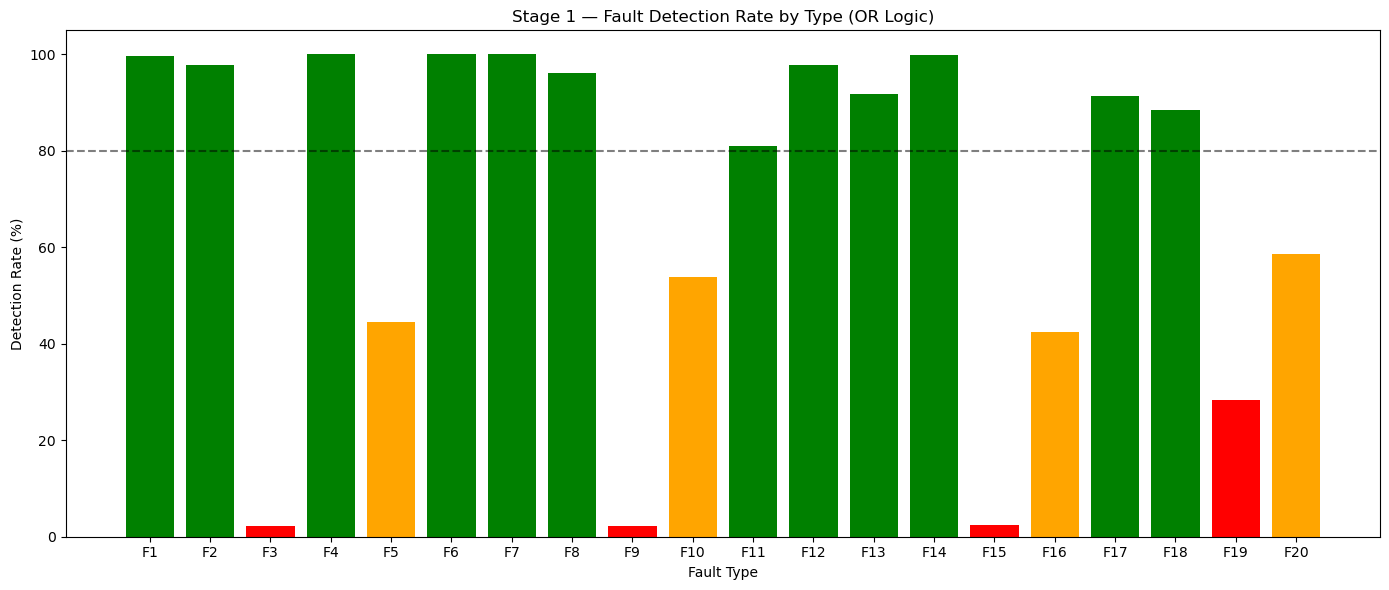

In [13]:
# Run this in your Stage 1 notebook
# It extracts actual OR detection rates automatically!

detection_rates = []
fault_numbers = []

for fault in sorted(np.unique(ft_labels)):
    fault_mask = ft_labels == fault
    combined_or = (
        (t2_faulty[fault_mask] > t2_threshold) |
        (spe_faulty[fault_mask] > spe_threshold)
    ).mean() * 100
    detection_rates.append(combined_or)
    fault_numbers.append(fault)

# Now plot with YOUR actual values!
faults = [f'F{i}' for i in fault_numbers]
colors = ['green' if r > 80 else 'orange' 
          if r > 30 else 'red' for r in detection_rates]

plt.figure(figsize=(14, 6))
plt.bar(faults, detection_rates, color=colors)
plt.axhline(y=80, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Fault Type')
plt.ylabel('Detection Rate (%)')
plt.title('Stage 1 — Fault Detection Rate by Type (OR Logic)')
plt.tight_layout()
plt.savefig('detection_rates.png', dpi=150)
plt.show()  